<a href="https://colab.research.google.com/github/ronakjindal1710/deep-learning/blob/main/Lab3(assignment).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install ucimlrepo

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
np.random.seed(42)

In [5]:
covertype = fetch_ucirepo(id=31)

X = covertype.data.features
y = covertype.data.targets

print("\nDataset loaded successfully!")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 rows of X:")
print(X.head())

print("\nFirst 5 rows of y:")
print(y.head())


Dataset loaded successfully!
X shape: (581012, 54)
y shape: (581012, 1)

First 5 rows of X:
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            

In [6]:
X = X.to_numpy()
y = y.iloc[:, 0].to_numpy()

print("\nAfter conversion:")
print("X shape:", X.shape)
print("y shape:", y.shape)


After conversion:
X shape: (581012, 54)
y shape: (581012,)


In [7]:
print("\nMissing values in X:", np.isnan(X).sum())
print("Missing values in y:", np.isnan(y).sum())
print("\nOriginal classes:")
print(np.unique(y))


Missing values in X: 0
Missing values in y: 0

Original classes:
[1 2 3 4 5 6 7]



Class Distribution:
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


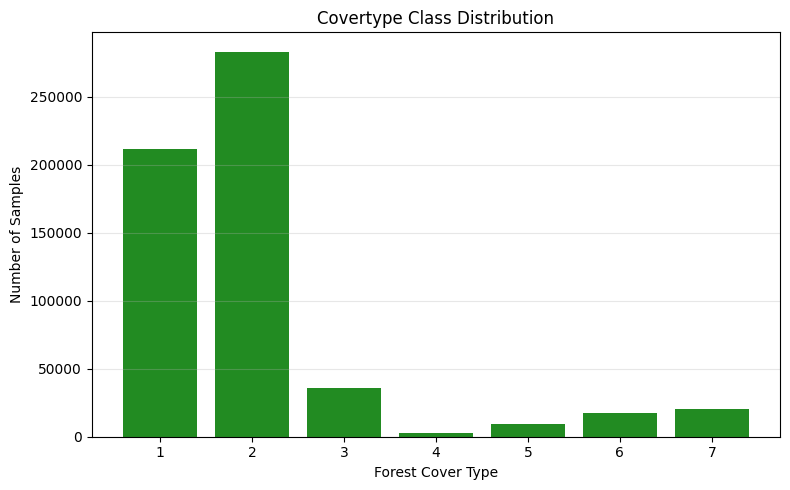

In [8]:
class_counts = pd.Series(y).value_counts().sort_index()
print("\nClass Distribution:")
print(class_counts)

plt.figure(figsize=(8, 5))
plt.bar(
    class_counts.index,
    class_counts.values,
    color="forestgreen"
)
plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Samples")
plt.title("Covertype Class Distribution")
plt.xticks(class_counts.index)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.tight_layout()
plt.show()

In [12]:
max_count = class_counts.max()
min_count = class_counts.min()

imbalance_ratio = max_count / min_count

print("\nMost frequent class:",
      class_counts.idxmax())

print("Least frequent class:",
      class_counts.idxmin())

print(
    "Imbalance ratio:",
    round(imbalance_ratio, 2)
)


Most frequent class: 2
Least frequent class: 4
Imbalance ratio: 103.13


In [14]:
y = y + 1

print("\nConverted classes:")
print(np.unique(y))


Converted classes:
[0 1 2 3 4 5 6]


In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


print("\nDataset Split:")
print("----------------------------")
print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)


Dataset Split:
----------------------------
Training   : (464809, 54)
Validation : (58101, 54)
Testing    : (58102, 54)


In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
print("\nFeature standardization completed.")


Feature standardization completed.


In [17]:
num_classes = 7
y_train_oh = np.eye(num_classes)[y_train]
y_val_oh = np.eye(num_classes)[y_val]
y_test_oh = np.eye(num_classes)[y_test]
print("\nOne-hot encoded shapes:")
print("y_train:", y_train_oh.shape)
print("y_val  :", y_val_oh.shape)
print("y_test :", y_test_oh.shape)


One-hot encoded shapes:
y_train: (464809, 7)
y_val  : (58101, 7)
y_test : (58102, 7)


In [18]:
N = len(y_train)
K = num_classes
train_class_counts = np.bincount(
    y_train,
    minlength=num_classes
)
class_weights = N / (
    K * train_class_counts
)
print("\nClass Weights")
print("----------------------------")
for c in range(num_classes):
    print(
        f"Class {c}: "
        f"Samples = {train_class_counts[c]}, "
        f"Weight = {class_weights[c]:.4f}"
    )



Class Weights
----------------------------
Class 0: Samples = 169472, Weight = 0.3918
Class 1: Samples = 226640, Weight = 0.2930
Class 2: Samples = 28603, Weight = 2.3215
Class 3: Samples = 2198, Weight = 30.2099
Class 4: Samples = 7594, Weight = 8.7439
Class 5: Samples = 13894, Weight = 4.7791
Class 6: Samples = 16408, Weight = 4.0469


In [19]:
input_size = 54
hidden1 = 64
hidden2 = 32
hidden3 = 16
output_size = 7

In [20]:
def he_initialization(fan_in, fan_out):

    return np.random.randn(
        fan_in,
        fan_out
    ) * np.sqrt(2.0 / fan_in)

W1 = he_initialization(
    input_size,
    hidden1
)
b1 = np.zeros(
    (1, hidden1)
)

W2 = he_initialization(
    hidden1,
    hidden2
)
b2 = np.zeros(
    (1, hidden2)
)
W3 = he_initialization(
    hidden2,
    hidden3
)
b3 = np.zeros(
    (1, hidden3)
)
W4 = he_initialization(
    hidden3,
    output_size
)
b4 = np.zeros(
    (1, output_size)
)

In [21]:
def relu(x):
    return np.maximum(
        0,
        x
    )

def relu_derivative(x):

    return (
        x > 0
    ).astype(float)

In [22]:
def softmax(x):
    x_shifted = (
        x -
        np.max(
            x,
            axis=1,
            keepdims=True
        )
    )
    exp_x = np.exp(
        x_shifted
    )
    return (
        exp_x /
        np.sum(
            exp_x,
            axis=1,
            keepdims=True
        )
    )

In [23]:
def forward(X):

    # Layer 1
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    # Layer 2
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    # Layer 3
    Z3 = A2 @ W3 + b3
    A3 = relu(Z3)

    # Output layer
    Z4 = A3 @ W4 + b4
    A4 = softmax(Z4)

    cache = (
        X,
        Z1,
        A1,
        Z2,
        A2,
        Z3,
        A3,
        Z4,
        A4
    )

    return A4, cache

In [24]:
def weighted_cross_entropy(
    y_true,
    y_pred,
    weights
):

    epsilon = 1e-12

    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    class_indices = np.argmax(
        y_true,
        axis=1
    )

    sample_weights = (
        weights[class_indices]
    )

    loss = -np.sum(
        sample_weights *
        np.sum(
            y_true *
            np.log(y_pred),
            axis=1
        )
    )

    loss /= np.sum(
        sample_weights
    )

    return loss

In [33]:
def backward(
    y_true,
    y_pred,
    cache,
    weights
):

    global W1, W2, W3, W4
    global b1, b2, b3, b4

    (
        X,
        Z1,
        A1,
        Z2,
        A2,
        Z3,
        A3,
        Z4,
        A4
    ) = cache

    # Get class index
    class_indices = np.argmax(
        y_true,
        axis=1
    )

    sample_weights = (
        weights[class_indices]
    )

    weight_sum = np.sum(
        sample_weights
    )
    dZ4 = (
        A4 - y_true
    )

    dZ4 *= sample_weights[:, None]

    dZ4 /= weight_sum

    dW4 = A3.T @ dZ4

    db4 = np.sum(
        dZ4,
        axis=0,
        keepdims=True
    )
    dA3 = dZ4 @ W4.T

    dZ3 = (
        dA3 *
        relu_derivative(Z3)
    )

    dW3 = A2.T @ dZ3

    db3 = np.sum(
        dZ3,
        axis=0,
        keepdims=True
    )
    dA2 = dZ3 @ W3.T

    dZ2 = (
        dA2 *
        relu_derivative(Z2)
    )

    dW2 = A1.T @ dZ2

    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    )
    dA1 = dZ2 @ W2.T

    dZ1 = (
        dA1 *
        relu_derivative(Z1)
    )

    dW1 = X.T @ dZ1

    db1 = np.sum(
        dZ1,
        axis=0,
        keepdims=True
    )


    return {
        "W1": dW1,
        "b1": db1,
        "W2": dW2,
        "b2": db2,
        "W3": dW3,
        "b3": db3,
        "W4": dW4,
        "b4": db4
    }

In [34]:
def update_parameters(
    gradients,
    learning_rate
):

    global W1, W2, W3, W4
    global b1, b2, b3, b4

    W1 -= (
        learning_rate *
        gradients["W1"]
    )

    b1 -= (
        learning_rate *
        gradients["b1"]
    )

    W2 -= (
        learning_rate *
        gradients["W2"]
    )

    b2 -= (
        learning_rate *
        gradients["b2"]
    )

    W3 -= (
        learning_rate *
        gradients["W3"]
    )

    b3 -= (
        learning_rate *
        gradients["b3"]
    )

    W4 -= (
        learning_rate *
        gradients["W4"]
    )

    b4 -= (
        learning_rate *
        gradients["b4"]
    )

In [35]:
def calculate_accuracy(
    y_true,
    y_pred
):

    true_labels = np.argmax(
        y_true,
        axis=1
    )

    predicted_labels = np.argmax(
        y_pred,
        axis=1
    )

    return np.mean(
        true_labels ==
        predicted_labels
    )

In [36]:
epochs = 100

batch_size = 128

learning_rate = 0.01

patience = 15


best_val_loss = np.inf

patience_counter = 0


history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}


print("\nStarting training...")
print("=" * 80)


for epoch in range(epochs):



    permutation = np.random.permutation(
        len(X_train)
    )

    X_train_shuffled = (
        X_train[permutation]
    )

    y_train_shuffled = (
        y_train_oh[permutation]
    )


    for start in range(
        0,
        len(X_train),
        batch_size
    ):

        end = start + batch_size

        X_batch = (
            X_train_shuffled[start:end]
        )

        y_batch = (
            y_train_shuffled[start:end]
        )


        # Forward
        predictions, cache = forward(
            X_batch
        )


        # Backward
        gradients = backward(
            y_batch,
            predictions,
            cache,
            class_weights
        )


        # Update
        update_parameters(
            gradients,
            learning_rate
        )



    train_predictions, _ = forward(
        X_train
    )

    train_loss = weighted_cross_entropy(
        y_train_oh,
        train_predictions,
        class_weights
    )

    train_accuracy = calculate_accuracy(
        y_train_oh,
        train_predictions
    )




    val_predictions, _ = forward(
        X_val
    )

    val_loss = weighted_cross_entropy(
        y_val_oh,
        val_predictions,
        class_weights
    )

    val_accuracy = calculate_accuracy(
        y_val_oh,
        val_predictions
    )


    # Save history

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )




    print(
        f"Epoch {epoch + 1:03d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )



    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0


        # Save best weights

        best_W1 = W1.copy()
        best_b1 = b1.copy()

        best_W2 = W2.copy()
        best_b2 = b2.copy()

        best_W3 = W3.copy()
        best_b3 = b3.copy()

        best_W4 = W4.copy()
        best_b4 = b4.copy()


    else:

        patience_counter += 1


        if patience_counter >= patience:

            print(
                "\nEarly stopping triggered."
            )

            break



Starting training...
Epoch 001/100 | Train Loss: 0.6891 | Val Loss: 0.7035 | Train Acc: 0.5959 | Val Acc: 0.5946
Epoch 002/100 | Train Loss: 0.6358 | Val Loss: 0.6419 | Train Acc: 0.6169 | Val Acc: 0.6171
Epoch 003/100 | Train Loss: 0.5719 | Val Loss: 0.5842 | Train Acc: 0.6486 | Val Acc: 0.6488
Epoch 004/100 | Train Loss: 0.5562 | Val Loss: 0.5728 | Train Acc: 0.6844 | Val Acc: 0.6857
Epoch 005/100 | Train Loss: 0.5376 | Val Loss: 0.5537 | Train Acc: 0.6858 | Val Acc: 0.6861
Epoch 006/100 | Train Loss: 0.5130 | Val Loss: 0.5219 | Train Acc: 0.6861 | Val Acc: 0.6883
Epoch 007/100 | Train Loss: 0.5258 | Val Loss: 0.5409 | Train Acc: 0.7061 | Val Acc: 0.7078
Epoch 008/100 | Train Loss: 0.4870 | Val Loss: 0.4949 | Train Acc: 0.6822 | Val Acc: 0.6832
Epoch 009/100 | Train Loss: 0.4801 | Val Loss: 0.4903 | Train Acc: 0.7125 | Val Acc: 0.7139
Epoch 010/100 | Train Loss: 0.4592 | Val Loss: 0.4725 | Train Acc: 0.7181 | Val Acc: 0.7201
Epoch 011/100 | Train Loss: 0.4716 | Val Loss: 0.4751 | Tr

In [37]:
W1 = best_W1
b1 = best_b1

W2 = best_W2
b2 = best_b2

W3 = best_W3
b3 = best_b3

W4 = best_W4
b4 = best_b4


print("\nBest model restored.")


Best model restored.


In [38]:
test_probabilities, _ = forward(
    X_test
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)


In [39]:
accuracy = accuracy_score(
    y_test,
    test_predictions
)

precision = precision_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)


print("\n")
print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print(
    f"Accuracy          : {accuracy:.4f}"
)

print(
    f"Macro Precision   : {precision:.4f}"
)

print(
    f"Macro Recall      : {recall:.4f}"
)

print(
    f"Macro F1 Score    : {f1:.4f}"
)




FINAL MODEL PERFORMANCE
Accuracy          : 0.8046
Macro Precision   : 0.7015
Macro Recall      : 0.8862
Macro F1 Score    : 0.7673


In [41]:
print("\nClassification Report:")
print("=" * 70)

print(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(7),
        target_names=[
            "Class 0",
            "Class 1",
            "Class 2",
            "Class 3",
            "Class 4",
            "Class 5",
            "Class 6"
        ],
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

     Class 0       0.75      0.88      0.81     21184
     Class 1       0.91      0.72      0.80     28331
     Class 2       0.81      0.86      0.83      3576
     Class 3       0.55      0.97      0.70       274
     Class 4       0.46      0.94      0.62       949
     Class 5       0.65      0.85      0.74      1737
     Class 6       0.77      0.97      0.86      2051

    accuracy                           0.80     58102
   macro avg       0.70      0.89      0.77     58102
weighted avg       0.83      0.80      0.81     58102



In [42]:
cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=np.arange(7)
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[18737  1810    19     0   111    11   496]
 [ 6038 20306   489     5   906   486   101]
 [    0    38  3065   169    16   288     0]
 [    0     0     5   267     0     2     0]
 [    5    25    17     0   896     6     0]
 [    1    13   193    47     4  1479     0]
 [   50     2     0     0     0     0  1999]]


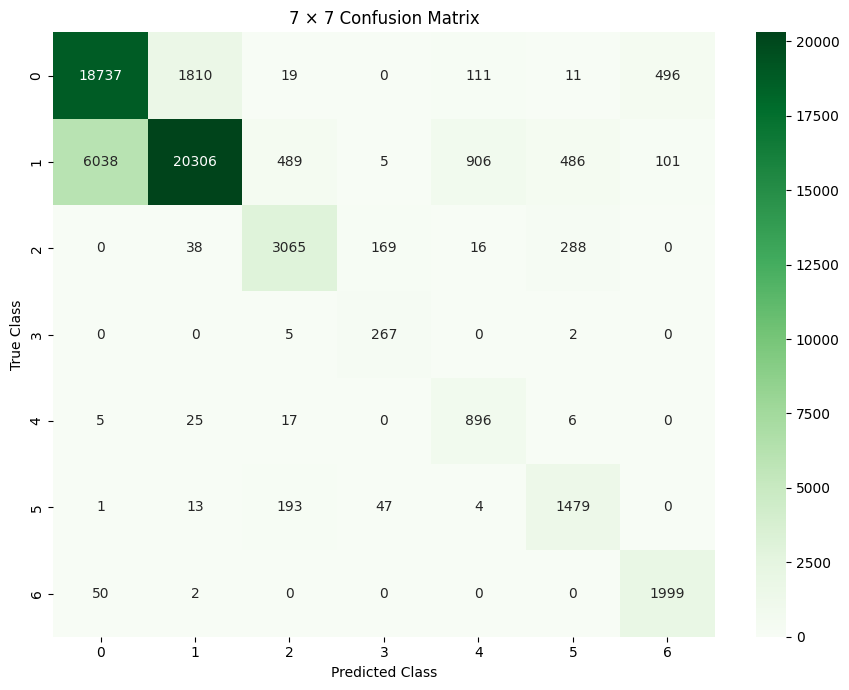

In [43]:
plt.figure(
    figsize=(9, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=np.arange(7),
    yticklabels=np.arange(7)
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.title(
    "7 × 7 Confusion Matrix"
)

plt.tight_layout()
plt.show()

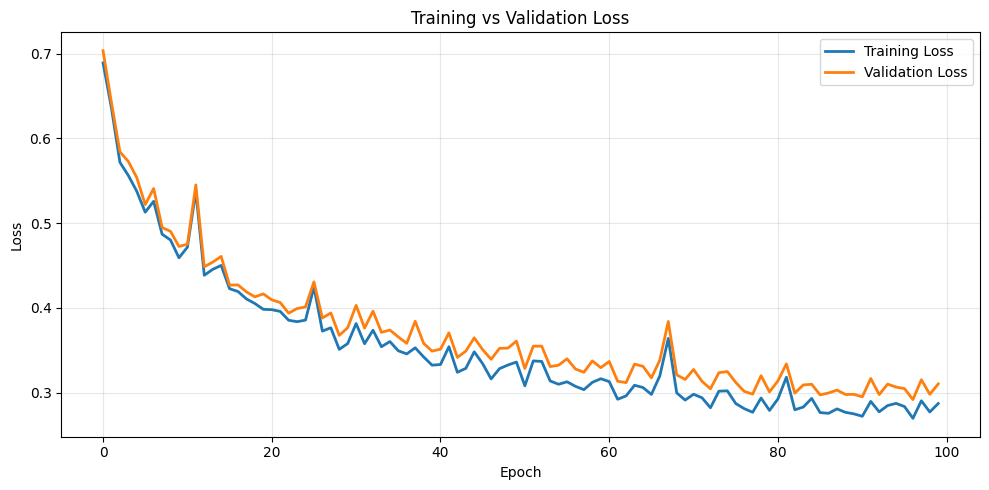

In [44]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history["train_loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

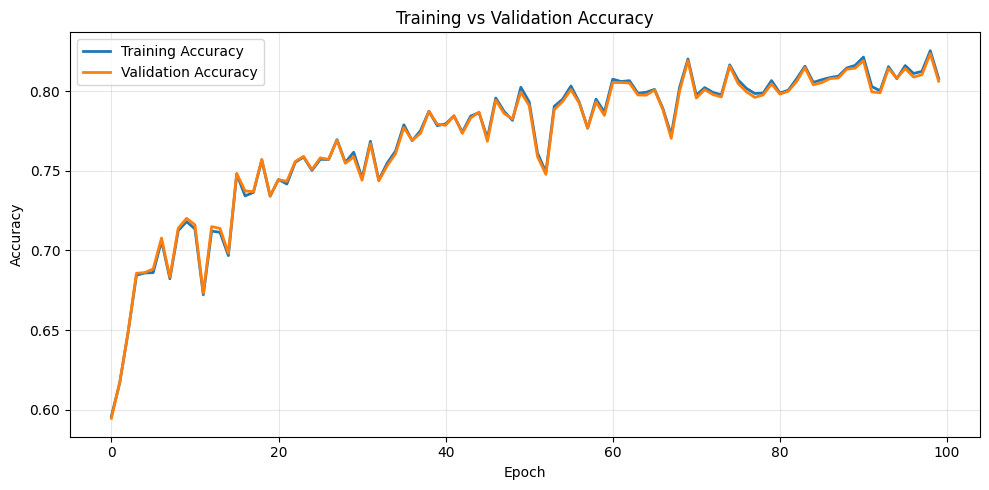

In [45]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history["train_accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

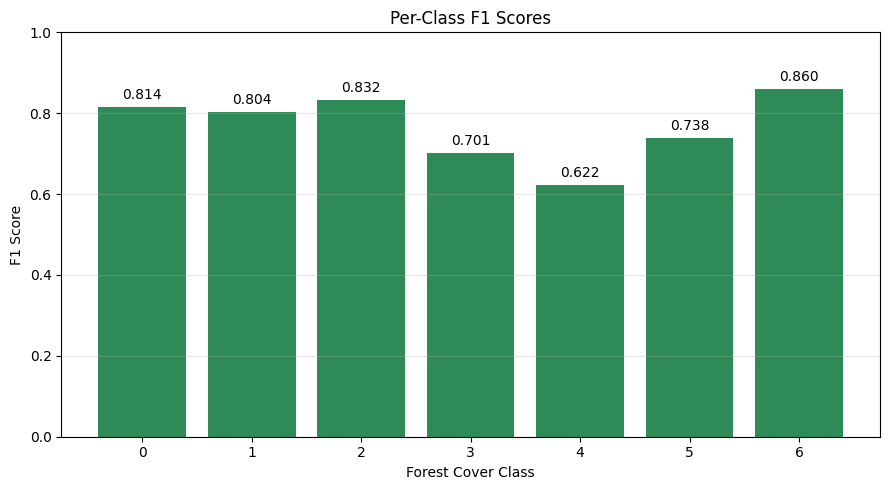

In [46]:
per_class_f1 = f1_score(
    y_test,
    test_predictions,
    average=None,
    labels=np.arange(7),
    zero_division=0
)

plt.figure(
    figsize=(9, 5)
)

bars = plt.bar(
    np.arange(7),
    per_class_f1,
    color="seagreen"
)

plt.xlabel("Forest Cover Class")
plt.ylabel("F1 Score")

plt.title(
    "Per-Class F1 Scores"
)

plt.xticks(
    np.arange(7)
)

plt.ylim(
    0,
    1
)


for bar, score in zip(
    bars,
    per_class_f1
):

    plt.text(
        bar.get_x() +
        bar.get_width() / 2,
        score + 0.02,
        f"{score:.3f}",
        ha="center"
    )


plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


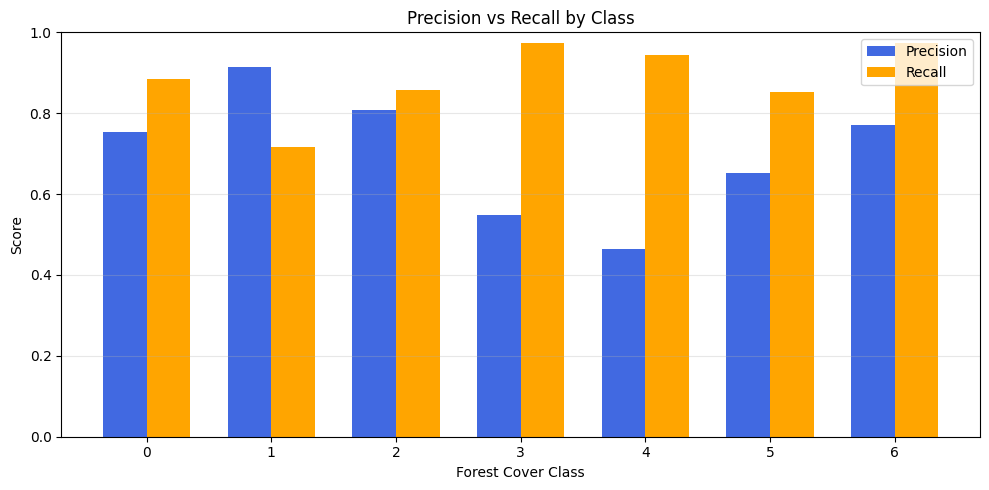

In [47]:
per_class_precision = precision_score(
    y_test,
    test_predictions,
    average=None,
    labels=np.arange(7),
    zero_division=0
)

per_class_recall = recall_score(
    y_test,
    test_predictions,
    average=None,
    labels=np.arange(7),
    zero_division=0
)


x = np.arange(7)

width = 0.35


plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x - width / 2,
    per_class_precision,
    width,
    label="Precision",
    color="royalblue"
)

plt.bar(
    x + width / 2,
    per_class_recall,
    width,
    label="Recall",
    color="orange"
)

plt.xlabel("Forest Cover Class")
plt.ylabel("Score")

plt.title(
    "Precision vs Recall by Class"
)

plt.xticks(x)

plt.ylim(
    0,
    1
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


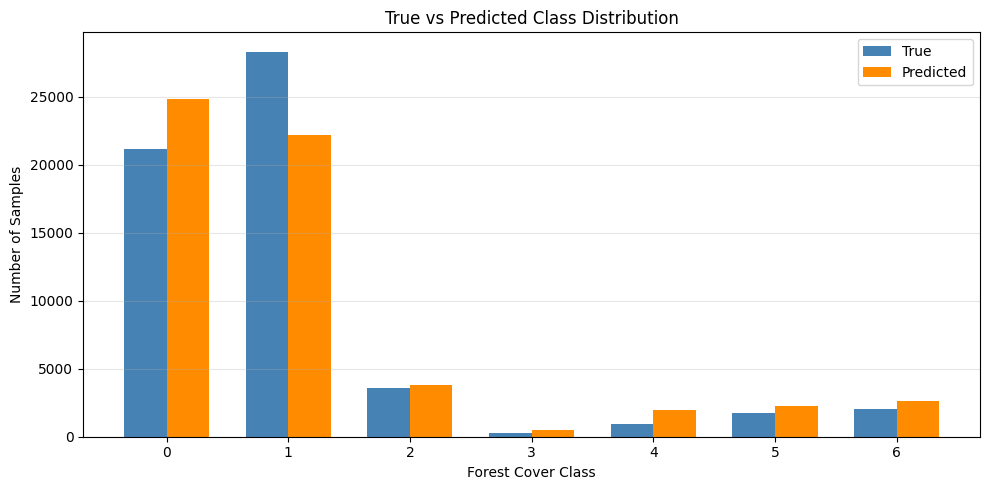

In [48]:

true_counts = np.bincount(
    y_test,
    minlength=7
)

predicted_counts = np.bincount(
    test_predictions,
    minlength=7
)


x = np.arange(7)

width = 0.35


plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x - width / 2,
    true_counts,
    width,
    label="True",
    color="steelblue"
)

plt.bar(
    x + width / 2,
    predicted_counts,
    width,
    label="Predicted",
    color="darkorange"
)

plt.xlabel("Forest Cover Class")
plt.ylabel("Number of Samples")

plt.title(
    "True vs Predicted Class Distribution"
)

plt.xticks(x)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [49]:
print("\n")
print("=" * 50)
print("FINAL SUMMARY")
print("=" * 50)

print(
    f"Test Accuracy       : {accuracy:.4f}"
)

print(
    f"Macro Precision     : {precision:.4f}"
)

print(
    f"Macro Recall        : {recall:.4f}"
)

print(
    f"Macro F1 Score      : {f1:.4f}"
)

print(
    f"Training Epochs     : "
    f"{len(history['train_loss'])}"
)

print("\nProgram completed successfully!")



FINAL SUMMARY
Test Accuracy       : 0.8046
Macro Precision     : 0.7015
Macro Recall        : 0.8862
Macro F1 Score      : 0.7673
Training Epochs     : 100

Program completed successfully!
